# Flood Arrival Time & Peak Flow Prediction — Okavango Delta

Predict two targets at **Maun Bridge** (GRDC 1357520) and other delta-outlet stations:
- **Flood arrival time**: month when flow first exceeds 50 % of annual peak (per water year).
- **Peak annual flow** (m³/s): maximum monthly discharge per water year.

**Predictors** tested individually and in combination:

| Source | Variable | Notes |
|---|---|---|
| DSWE Landsat | monthly inundation area km² | 1999–present |
| DSWE Sentinel-2 | monthly inundation area km² | 2017–present |
| CYGNSS | monthly inundation area km² | 2017–present |
| CHIRPS | rainfall mm/month (delta + highlands) | 1981–present |
| GRACE | TWS anomaly cm | 2002–present |
| Mohembo Q | monthly mean discharge m³/s | 1975–present |

**Target stations** within the Okavango polygon:
- 1357100 MOHEMBO/MTAEMBO — inlet (also used as predictor)
- **1357520 MAUN BRIDGE — primary target**
- 1357530 BORO JUNCTION
- 1357501 SAMEDUPE (Boteti R.)
- 1357500 RAKOPS (Boteti R.)

In [6]:
# ── 1. Imports & paths ────────────────────────────────────────────────────────
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    TimeSeriesSplit, LeaveOneOut, cross_val_score, cross_val_predict
)
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.exceptions import UndefinedMetricWarning

from src.grdc_io import read_grdc_cmd_file, pick_discharge_column
from src.time_utils import water_year

from src.grdc_io import read_grdc_cmd_file, pick_discharge_column
from src.time_utils import water_year

from src.grdc_io import read_grdc_cmd_file, pick_discharge_column
from src.time_utils import water_year

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

ROOT    = Path("..")
DATA    = ROOT / "data"
GRDC    = ROOT / "data" / "GRDC_station_data"
FIG_OUT = ROOT / "figures" / "flood_prediction"
FIG_OUT.mkdir(parents=True, exist_ok=True)


print("Setup complete. FIG_OUT:", FIG_OUT.resolve())


Setup complete. FIG_OUT: /Users/octaviacrompton/Projects/dswe-inman-lyons/figures/flood_prediction


## 2  Define station metadata & load GRDC daily discharge

In [7]:
# All gauges inside / at the boundary of the Okavango polygon
STATIONS = {
    1357100: {"name": "Mohembo",       "river": "Okavango",    "role": "inlet"},
    1357520: {"name": "Maun Bridge",   "river": "Thamalakane", "role": "target"},
    1357530: {"name": "Boro Junction", "river": "Boro",        "role": "target"},
    1357535: {"name": "Pantoon Site",  "river": "Boro",        "role": "target"},
    1357501: {"name": "Samedupe",      "river": "Boteti",      "role": "target"},
    1357500: {"name": "Rakops",        "river": "Boteti",      "role": "target"},
    1357510: {"name": "Bund",          "river": "Lake River",  "role": "target"},
}

# Station GeoDataFrame for spatial plots (using src.grdc_io)
meta_rows = []
for sid, info in STATIONS.items():
    fp = GRDC / f"{sid}_Q_Day.Cmd.txt"
    lat = lon = None
    if fp.exists():
        meta, _ = read_grdc_cmd_file(fp)
        lat, lon = meta.get("lat"), meta.get("lon")
    meta_rows.append({"station_id": sid, "name": info["name"],
                       "river": info["river"], "role": info["role"],
                       "lat": lat, "lon": lon})

meta_df = pd.DataFrame(meta_rows)
station_gdf = gpd.GeoDataFrame(
    meta_df.dropna(subset=["lat", "lon"]),
    geometry=gpd.points_from_xy(
        meta_df.dropna(subset=["lat","lon"])["lon"],
        meta_df.dropna(subset=["lat","lon"])["lat"]
    ),
    crs="EPSG:4326"
)
display(meta_df[["station_id","name","river","role","lat","lon"]])

,station_id,name,river,role,lat,lon
0,1357100,Mohembo,Okavango,inlet,-18.283333,21.800000
1,1357520,Maun Bridge,Thamalakane,target,-19.989583,23.431250
2,1357530,Boro Junction,Boro,target,-19.916667,23.400000
3,1357535,Pantoon Site,Boro,target,-19.899230,23.484460
4,1357501,Samedupe,Boteti,target,-20.116667,23.516667
5,1357500,Rakops,Boteti,target,-21.000000,24.366667
6,1357510,Bund,Lake River,target,-20.133333,23.350000


In [8]:
# read_grdc_daily replaced by src.grdc_io.read_grdc_cmd_file
def read_grdc_daily(station_id: int, missing_val: float = -999.0) -> pd.DataFrame:
    fp = GRDC / f"{station_id}_Q_Day.Cmd.txt"
    if not fp.exists():
        return pd.DataFrame()
    _, ts = read_grdc_cmd_file(fp)
    q_col = pick_discharge_column(ts)
    return (ts[[q_col]].rename(columns={q_col: 'Q_m3s'})
            .reset_index()
            .rename(columns={"datetime": "date"}))

def daily_to_monthly(df_daily: pd.DataFrame, min_days: int = 15) -> pd.Series:
    """Monthly mean Q; NaN where < min_days observations."""
    df = df_daily.copy()
    df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
    agg = df.groupby("month")["Q_m3s"].agg(mean_Q="mean", n_days="count")
    agg.loc[agg["n_days"] < min_days, "mean_Q"] = np.nan
    return agg["mean_Q"].rename("Q_m3s")


daily_q   = {sid: read_grdc_daily(sid) for sid in STATIONS}
monthly_q = {sid: daily_to_monthly(df) for sid, df in daily_q.items() if not df.empty}

for sid, s in monthly_q.items():
    n = s.notna().sum()
    print(f"  {sid}  {STATIONS[sid]['name']:20s}: "
          f"{s.first_valid_index().date()} – {s.last_valid_index().date()}  ({n} months)")

  1357100  Mohembo             : 1974-12-01 – 2024-01-01  (546 months)
  1357520  Maun Bridge         : 1970-10-01 – 2024-06-01  (271 months)
  1357530  Boro Junction       : 1969-10-01 – 2024-07-01  (314 months)
  1357535  Pantoon Site        : 1969-10-01 – 2005-10-01  (306 months)
  1357501  Samedupe            : 1970-10-01 – 2024-07-01  (222 months)
  1357500  Rakops              : 1971-10-01 – 2021-09-01  (469 months)
  1357510  Bund                : 1972-10-01 – 1990-09-01  (124 months)


## 3  Load remote-sensing & climate predictors (DSWE, CYGNSS, CHIRPS, GRACE)

In [9]:
def to_month_start(df_or_series, col=None):
    """Normalize a DatetimeIndex or a date column to month-start.
    Deduplicates by taking the mean (numeric columns only) per month."""
    if col:
        df_or_series[col] = pd.to_datetime(df_or_series[col]).dt.to_period("M").dt.to_timestamp()
        df_or_series = df_or_series.set_index(col).sort_index()
        return df_or_series.groupby(level=0).mean(numeric_only=True)
    idx = pd.to_datetime(df_or_series.index).to_period("M").to_timestamp()
    df_or_series.index = idx
    df_or_series = df_or_series.sort_index()
    return df_or_series.groupby(level=0).mean(numeric_only=True)

# ── DSWE Landsat ─────────────────────────────────────────────────────────────
raw_ls = pd.read_csv(DATA / "monthly_landsat_dswe.csv", parse_dates=["date"])
dswe_ls = to_month_start(raw_ls.set_index("date"))
dswe_ls_col = dswe_ls.columns[0]   # first numeric column = inundation area
print("DSWE Landsat:  ", dswe_ls.shape, dswe_ls_col)

# ── DSWE Sentinel-2 ──────────────────────────────────────────────────────────
raw_s2 = pd.read_csv(DATA / "monthly_sentinel2_dswe.csv", parse_dates=["date"])
dswe_s2 = to_month_start(raw_s2.set_index("date"))
dswe_s2_col = dswe_s2.columns[0]
print("DSWE Sentinel-2:", dswe_s2.shape, dswe_s2_col)

# ── Combined monthly (CYGNSS + CHIRPS already merged) ────────────────────────
combined = (pd.read_csv(DATA / "okavango_combined_monthly_1990plus.csv",
                         parse_dates=["month"])
              .pipe(to_month_start, col="month"))

cygnss          = combined[["cygnss_km2"]].copy()
chirps_delta    = combined[["rain_delta_mm"]].copy()
chirps_highland = combined[["rain_highlands_mm"]].copy()

# ── GRACE ─────────────────────────────────────────────────────────────────────
grace_dir = DATA / "grace_okavango_out"
grace_files = sorted(grace_dir.glob("*.csv"))
if grace_files:
    grace_raw = pd.read_csv(grace_files[0], parse_dates=[0])
    grace_raw.columns = ["date"] + [f"grace_{c}" for c in grace_raw.columns[1:]]
    grace = to_month_start(grace_raw, col="date")
    print("GRACE:          ", grace.shape, list(grace.columns[:3]))
else:
    grace = None
    print("GRACE: not found — will be excluded from feature set")

print("\nCYGNSS:",    cygnss.shape)
print("CHIRPS delta:", chirps_delta.shape)
print("CHIRPS highland:", chirps_highland.shape)


DSWE Landsat:   (378, 5) Unnamed: 0
DSWE Sentinel-2: (81, 5) Unnamed: 0
GRACE:           (245, 2) ['grace_lwe_mean_cm', 'grace_lwe_std_cm']

CYGNSS: (432, 1)
CHIRPS delta: (432, 1)
CHIRPS highland: (432, 1)


## 4  Build feature matrix with lagged predictors

In [10]:
# ── Assemble raw feature frame ─────────────────────────────────────────────
feat_parts = {
    "dswe_ls_km2":        dswe_ls[[dswe_ls_col]].rename(columns={dswe_ls_col: "dswe_ls_km2"}),
    "dswe_s2_km2":        dswe_s2[[dswe_s2_col]].rename(columns={dswe_s2_col: "dswe_s2_km2"}),
    "cygnss_km2":         cygnss,
    "rain_delta_mm":      chirps_delta,
    "rain_highland_mm":   chirps_highland,
}
if grace is not None:
    feat_parts["grace_ew_mm"] = grace.iloc[:, :1].rename(columns={grace.columns[0]: "grace_ew_mm"})

features_raw = (pd.concat(feat_parts.values(), axis=1)
                  .sort_index())

# ── Add month seasonality ──────────────────────────────────────────────────
features_raw["month_sin"] = np.sin(2 * np.pi * features_raw.index.month / 12)
features_raw["month_cos"] = np.cos(2 * np.pi * features_raw.index.month / 12)

# ── Mohembo discharge as predictor ───────────────────────────────────────────
if "1357100" in monthly_q:
    moh_m = monthly_q["1357100"].rename("q_mohembo_m3s")
    moh_m.index = pd.to_datetime(moh_m.index).to_period("M").to_timestamp()
    features_raw = features_raw.join(moh_m, how="left")

print("Raw features:", features_raw.shape)
print(features_raw.dtypes)
features_raw.tail(6)

Raw features: (457, 8)
dswe_ls_km2          float64
dswe_s2_km2          float64
cygnss_km2           float64
rain_delta_mm        float64
rain_highlands_mm    float64
grace_ew_mm          float64
month_sin            float64
month_cos            float64
dtype: object


,dswe_ls_km2,dswe_s2_km2,cygnss_km2,rain_delta_mm,rain_highlands_mm,grace_ew_mm,month_sin,month_cos
2025-07-01,225.0,48.0,9966.143264,0.154539,0.002285,-3.026587,-5.000000e-01,-8.660254e-01
2025-08-01,258.0,55.0,10407.679511,0.000000,0.012782,NaN,-8.660254e-01,-5.000000e-01
2025-09-01,290.0,NaN,NaN,NaN,NaN,NaN,-1.000000e+00,-1.836970e-16
2025-10-01,317.0,NaN,9086.763142,NaN,NaN,NaN,-8.660254e-01,5.000000e-01
2025-11-01,348.0,NaN,NaN,NaN,NaN,NaN,-5.000000e-01,8.660254e-01
2025-12-01,377.0,NaN,NaN,NaN,NaN,NaN,-2.449294e-16,1.000000e+00


In [11]:
PREDICTOR_COLS = [c for c in features_raw.columns
                  if c not in ("month_sin", "month_cos")]
LAGS = [1, 2, 3, 4, 6, 9, 12]

lagged_parts = [features_raw[["month_sin", "month_cos"]]]  # seasonality at time t

for col in PREDICTOR_COLS:
    s = features_raw[col]
    # individual lags
    for lag in LAGS:
        lagged_parts.append(s.shift(lag).rename(f"{col}_lag{lag}"))
    # rolling 3-month and 6-month means (then lag 1 so no leakage)
    for win in (3, 6):
        lagged_parts.append(
            s.rolling(win, min_periods=win // 2).mean()
             .shift(1).rename(f"{col}_roll{win}m")
        )

feat_lagged = pd.concat(lagged_parts, axis=1).dropna(how="all")
print("Lagged feature frame:", feat_lagged.shape)
feat_lagged.head(3)

Lagged feature frame: (457, 56)


,month_sin,month_cos,dswe_ls_km2_lag1,dswe_ls_km2_lag2,dswe_ls_km2_lag3,dswe_ls_km2_lag4,dswe_ls_km2_lag6,dswe_ls_km2_lag9,dswe_ls_km2_lag12,dswe_ls_km2_roll3m,...,rain_highlands_mm_roll6m,grace_ew_mm_lag1,grace_ew_mm_lag2,grace_ew_mm_lag3,grace_ew_mm_lag4,grace_ew_mm_lag6,grace_ew_mm_lag9,grace_ew_mm_lag12,grace_ew_mm_roll3m,grace_ew_mm_roll6m
1984-06-01,1.224647e-16,-1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984-07-01,-5.000000e-01,-8.660254e-01,162.0,NaN,NaN,NaN,NaN,NaN,NaN,162.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984-09-01,-1.000000e+00,-1.836970e-16,194.0,162.0,NaN,NaN,NaN,NaN,NaN,178.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 5  Target variables — annual peak flow and flood-arrival month

In [12]:
FLOOD_MONTHS = {3, 4, 5, 6, 7}   # Mar–Jul window for Okavango flood season

def annual_peaks(monthly_series, wyear_fn=water_year):
    """Return a Series of annual peak discharge indexed by water year."""
    s = monthly_series.copy().dropna()
    s.index = pd.to_datetime(s.index)
    wy = s.index.map(wyear_fn)
    return s.groupby(wy).max()

def arrival_month(monthly_series, threshold_quantile=0.4, flood_months=FLOOD_MONTHS):
    """
    For each water year return the first month (1-12) within flood_months that
    exceeds the threshold quantile of the series.  Returns NaN if not reached.
    """
    s = monthly_series.dropna()
    threshold = s.quantile(threshold_quantile)
    s.index = pd.to_datetime(s.index)
    wy_col = s.index.map(water_year)
    results = {}
    for wy, grp in s.groupby(wy_col):
        flood_grp = grp[grp.index.month.isin(flood_months)]
        above = flood_grp[flood_grp > threshold]
        results[wy] = above.index.month.min() if len(above) else np.nan
    return pd.Series(results, name="arrival_month").dropna()

# ── Build targets for all stations ───────────────────────────────────────────
targets = {}     # targets[stn_id] = {"peak_Q": Series, "arrival_month": Series}

for stn_id, q_monthly in monthly_q.items():
    if q_monthly.dropna().empty:
        continue
    peaks     = annual_peaks(q_monthly)
    arrivals  = arrival_month(q_monthly)

    if not peaks.empty:
        targets[stn_id] = {
            "peak_Q":       peaks.rename("peak_Q_m3s"),
            "arrival_month": arrivals,
        }
        print(f"Station {stn_id} ({STATIONS[stn_id]['name']}):  "
              f"{len(peaks)} peak-Q years, {len(arrivals)} arrival years")

Station 1357100 (Mohembo):  50 peak-Q years, 49 arrival years
Station 1357520 (Maun Bridge):  34 peak-Q years, 20 arrival years
Station 1357530 (Boro Junction):  36 peak-Q years, 24 arrival years
Station 1357535 (Pantoon Site):  35 peak-Q years, 24 arrival years
Station 1357501 (Samedupe):  26 peak-Q years, 16 arrival years
Station 1357500 (Rakops):  48 peak-Q years, 17 arrival years
Station 1357510 (Bund):  14 peak-Q years, 10 arrival years


## 6  Lagged cross-correlation analysis (Maun Bridge)

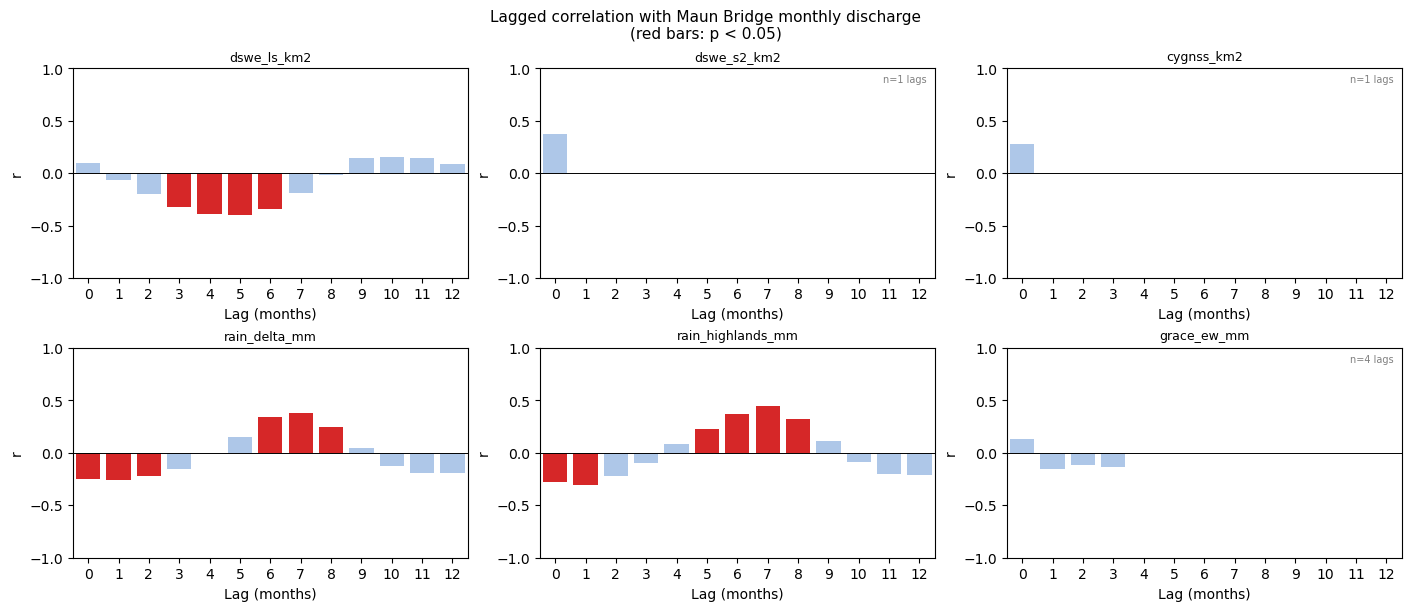

,predictor,best_lag_months,r,p
4,rain_highlands_mm,7,0.450,0.0000
0,dswe_ls_km2,5,-0.397,0.0001
3,rain_delta_mm,7,0.376,0.0008
1,dswe_s2_km2,0,0.371,0.3256
2,cygnss_km2,0,0.281,0.4632
5,grace_ew_mm,1,-0.158,0.6419


In [13]:
from scipy.stats import pearsonr

MAUN_ID = 1357520   # Maun Bridge — primary target station (integer, matches monthly_q/targets keys)
MAX_LAG = 12

def lagged_correlation(predictor: pd.Series, target: pd.Series,
                       max_lag: int = MAX_LAG) -> pd.DataFrame:
    """Pearson r and p-value for predictor shifted by 0..max_lag months
    relative to the target (positive lag = predictor leads target)."""
    df = pd.concat([predictor.rename("pred"), target.rename("tgt")],
                   axis=1).dropna()
    rows = []
    for lag in range(0, max_lag + 1):
        paired = pd.concat([df["pred"].shift(lag), df["tgt"]], axis=1).dropna()
        if len(paired) < 5:
            continue
        # skip constant arrays — pearsonr is undefined for zero-variance inputs
        if paired.iloc[:, 0].std() == 0 or paired.iloc[:, 1].std() == 0:
            continue
        r, p = pearsonr(paired.iloc[:, 0], paired.iloc[:, 1])
        rows.append({"lag_months": lag, "r": r, "p": p})
    return pd.DataFrame(rows)

# ── Run CCF for Maun monthly discharge vs each predictor ─────────────────────
maun_q_monthly = monthly_q.get(MAUN_ID, pd.Series(dtype=float))
if not maun_q_monthly.empty:
    maun_q_monthly.index = pd.to_datetime(maun_q_monthly.index).to_period("M").to_timestamp()

ccf_results = {}
for pcol in PREDICTOR_COLS:
    if pcol not in features_raw.columns:
        continue
    ccf_results[pcol] = lagged_correlation(features_raw[pcol], maun_q_monthly)

# ── Plot ──────────────────────────────────────────────────────────────────────
n_preds = len(ccf_results)
ncols = 3
nrows = int(np.ceil(n_preds / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), constrained_layout=True)
axes = np.array(axes).flatten()

for ax, (pcol, df_ccf) in zip(axes, ccf_results.items()):
    if not df_ccf.empty:
        colors = ["#d62728" if p < 0.05 else "#aec7e8" for p in df_ccf["p"]]
        ax.bar(df_ccf["lag_months"], df_ccf["r"], color=colors, width=0.8)
    else:
        ax.text(0.5, 0.5, "insufficient overlap", ha="center", va="center",
                transform=ax.transAxes, fontsize=8, color="grey")
    if len(df_ccf) < 5:
        ax.text(0.98, 0.97, f"n={len(df_ccf)} lags", ha="right", va="top",
                transform=ax.transAxes, fontsize=7, color="grey")
    ax.axhline(0, lw=0.7, color="k")
    ax.set_title(pcol, fontsize=9)
    ax.set_xlabel("Lag (months)")
    ax.set_ylabel("r")
    ax.set_xlim(-0.5, MAX_LAG + 0.5)
    ax.set_xticks(range(0, MAX_LAG + 1))
    ax.set_ylim(-1, 1)

for ax in axes[n_preds:]:
    ax.set_visible(False)

fig.suptitle("Lagged correlation with Maun Bridge monthly discharge\n"
             "(red bars: p < 0.05)", fontsize=11)
FIG_OUT.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_OUT / "lagged_ccf_maun.png", dpi=150)
plt.show()

# ── Best-lag summary table ─────────────────────────────────────────────────
lag_rows = []
for pcol, df_ccf in ccf_results.items():
    if df_ccf.empty:
        continue
    best = df_ccf.loc[df_ccf["r"].abs().idxmax()]
    lag_rows.append({"predictor": pcol,
                     "best_lag_months": int(best["lag_months"]),
                     "r": round(best["r"], 3),
                     "p": round(best["p"], 4)})

lag_df = pd.DataFrame(lag_rows).sort_values("r", key=abs, ascending=False)
lag_df


## 7  Monthly discharge prediction — cross-validated model comparison

In [14]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error

# ── Predictor set definitions ─────────────────────────────────────────────────
def _lag_cols(base, lags=LAGS):
    return [f"{base}_lag{L}" for L in lags] + [f"{base}_roll3m", f"{base}_roll6m"]

SEASONALITY = ["month_sin", "month_cos"]

PRED_SETS = {
    "DSWE_LS":          SEASONALITY + _lag_cols("dswe_ls_km2"),
    "DSWE_S2":          SEASONALITY + _lag_cols("dswe_s2_km2"),
    "CYGNSS":           SEASONALITY + _lag_cols("cygnss_km2"),
    "CHIRPS_delta":     SEASONALITY + _lag_cols("rain_delta_mm"),
    "CHIRPS_highland":  SEASONALITY + _lag_cols("rain_highland_mm"),
    "DSWE_LS+CYGNSS":   SEASONALITY + _lag_cols("dswe_ls_km2") + _lag_cols("cygnss_km2"),
    "DSWE+CHIRPS":      SEASONALITY + _lag_cols("dswe_ls_km2") + _lag_cols("rain_delta_mm"),
    "CYGNSS+CHIRPS":    SEASONALITY + _lag_cols("cygnss_km2")  + _lag_cols("rain_delta_mm"),
    "Mohembo":          (SEASONALITY + _lag_cols("q_mohembo_m3s")
                         if "q_mohembo_m3s" in feat_lagged.columns else []),
    "All_RS":           (SEASONALITY + _lag_cols("dswe_ls_km2") + _lag_cols("cygnss_km2")
                         + _lag_cols("rain_delta_mm") + _lag_cols("rain_highland_mm")),
}
if grace is not None:
    PRED_SETS["GRACE"]   = SEASONALITY + _lag_cols("grace_ew_mm")
    PRED_SETS["All_RS+GRACE"] = PRED_SETS["All_RS"] + _lag_cols("grace_ew_mm")

# remove empty sets
PRED_SETS = {k: v for k, v in PRED_SETS.items() if v and len(v) > 2}

# ── ML model definitions ──────────────────────────────────────────────────────
MODELS = {
    "Ridge":    Pipeline([("scaler", StandardScaler()), ("reg", Ridge(alpha=1.0))]),
    "RF":       RandomForestRegressor(n_estimators=200, max_depth=5,
                                      min_samples_leaf=3, random_state=42),
    "GradBoost": GradientBoostingRegressor(n_estimators=200, max_depth=3,
                                           learning_rate=0.05, random_state=42),
}

print("Predictor sets:", list(PRED_SETS.keys()))
print("Models:        ", list(MODELS.keys()))

Predictor sets: ['DSWE_LS', 'DSWE_S2', 'CYGNSS', 'CHIRPS_delta', 'CHIRPS_highland', 'DSWE_LS+CYGNSS', 'DSWE+CHIRPS', 'CYGNSS+CHIRPS', 'All_RS', 'GRACE', 'All_RS+GRACE']
Models:         ['Ridge', 'RF', 'GradBoost']


In [15]:
def evaluate_predictor_set(feat_df, target_monthly, pred_cols,
                           n_splits=5, models=MODELS):
    """
    Time-series CV (n_splits folds) for each model.
    Returns a dict  model_name -> mean R² over folds.
    """
    # align and drop missing
    avail_cols = [c for c in pred_cols if c in feat_df.columns]
    if not avail_cols:
        return {}
    df = feat_df[avail_cols].join(target_monthly.rename("y")).dropna()
    if len(df) < n_splits * 2:
        return {}
    X, y = df[avail_cols].values, df["y"].values

    tscv = TimeSeriesSplit(n_splits=n_splits)
    out = {}
    for mname, model in models.items():
        import copy
        m = copy.deepcopy(model)
        with warnings.catch_warnings():
            warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
            scores = cross_val_score(m, X, y, cv=tscv, scoring="r2")
        # drop NaN scores from folds with insufficient test samples
        valid_scores = scores[~np.isnan(scores)]
        out[mname] = round(float(valid_scores.mean()), 3) if len(valid_scores) else np.nan
    return out

# ── Evaluate Maun Bridge monthly discharge ───────────────────────────────────
maun_q = monthly_q.get(MAUN_ID, pd.Series(dtype=float))
if not maun_q.empty:
    maun_q.index = pd.to_datetime(maun_q.index).to_period("M").to_timestamp()

results_rows = []
for pset_name, pcols in PRED_SETS.items():
    scores = evaluate_predictor_set(feat_lagged, maun_q, pcols)
    for mname, r2 in scores.items():
        results_rows.append({"predictor_set": pset_name, "model": mname, "cv_R2": r2})

results_df = (pd.DataFrame(results_rows)
               .pivot(index="predictor_set", columns="model", values="cv_R2")
               .sort_values("Ridge", ascending=False))
print(f"Monthly prediction results for Maun Bridge ({MAUN_ID}):")
results_df


Monthly prediction results for Maun Bridge (1357520):


model,GradBoost,RF,Ridge
predictor_set,,,
CHIRPS_delta,-29.989,-18.821,-22.685
DSWE+CHIRPS,-37.360,-30.199,-32.123
CHIRPS_highland,-114.292,-107.893,-107.888
DSWE_LS,-119193.392,-203601.221,-353078.611
GRACE,NaN,NaN,NaN


## 8  Annual flood timing & peak-flow prediction (leave-one-out CV)

In [16]:
from sklearn.model_selection import LeaveOneOut
import copy

def build_annual_X(feat_df, year_series, months_before=3,
                   agg_cols=None, wy_fn=water_year):
    """
    For each water year present in `year_series`, compute a feature vector
    from the `months_before` months preceding the flood season (i.e. Jan–Mar
    of the calendar year = Oct–Dec + Jan of the preceding water year).
    """
    if agg_cols is None:
        agg_cols = [c for c in feat_df.columns
                    if c not in ("month_sin", "month_cos")]
    rows = {}
    for wy in year_series.index:
        # preceding months: Oct–Dec of wy-1 and Jan–Mar of wy
        pre_start = pd.Timestamp(f"{wy - 1}-10-01")
        pre_end   = pd.Timestamp(f"{wy}-03-01")
        window    = feat_df.loc[pre_start:pre_end, agg_cols].dropna(how="all")
        if window.empty:
            continue
        row = {}
        for col in window.columns:
            row[f"{col}_mean_pre"] = window[col].mean()
            row[f"{col}_max_pre"]  = window[col].max()
        rows[wy] = row
    return pd.DataFrame.from_dict(rows, orient="index")

def loo_cv_ridge(X_df, y_series, alpha=1.0):
    """Leave-one-out Ridge CV; returns DataFrame with obs/pred and RMSE."""
    common = X_df.index.intersection(y_series.index)
    X_df   = X_df.loc[common].dropna(axis=1)
    y_s    = y_series.loc[common]
    if len(common) < 4:
        return pd.DataFrame(), np.nan, np.nan

    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_df)
    loo = LeaveOneOut()
    preds = []
    for train_idx, test_idx in loo.split(X_s):
        m = Ridge(alpha=alpha)
        m.fit(X_s[train_idx], y_s.iloc[train_idx])
        preds.append(m.predict(X_s[test_idx])[0])

    pred_s = pd.Series(preds, index=common, name="predicted")
    obs_s  = y_s.rename("observed")
    df_out = pd.concat([obs_s, pred_s], axis=1)
    rmse   = np.sqrt(((df_out["observed"] - df_out["predicted"]) ** 2).mean())
    r2     = r2_score(df_out["observed"], df_out["predicted"])
    return df_out, rmse, r2

# ── Run for Maun Bridge ───────────────────────────────────────────────────────
annual_results = {}
for target_key in ("peak_Q", "arrival_month"):
    if MAUN_ID not in targets or target_key not in targets[MAUN_ID]:
        continue
    y_annual = targets[MAUN_ID][target_key]
    best_set, best_r2, best_df = None, -np.inf, None
    for pset_name, pcols in PRED_SETS.items():
        avail = [c for c in pcols if c in feat_lagged.columns]
        if not avail:
            continue
        X_annual = build_annual_X(feat_lagged[avail], y_annual, agg_cols=avail)
        df_out, rmse, r2 = loo_cv_ridge(X_annual, y_annual)
        if r2 > best_r2 and not df_out.empty:
            best_r2, best_set, best_df = r2, pset_name, df_out
    annual_results[target_key] = {"r2": best_r2, "pred_set": best_set, "df": best_df}
    print(f"  {target_key}: best predictor set = '{best_set}',  LOO R² = {best_r2:.3f}")

  peak_Q: best predictor set = 'DSWE_LS',  LOO R² = 0.360
  arrival_month: best predictor set = 'DSWE_LS',  LOO R² = -1.262


## 9  Visualizations

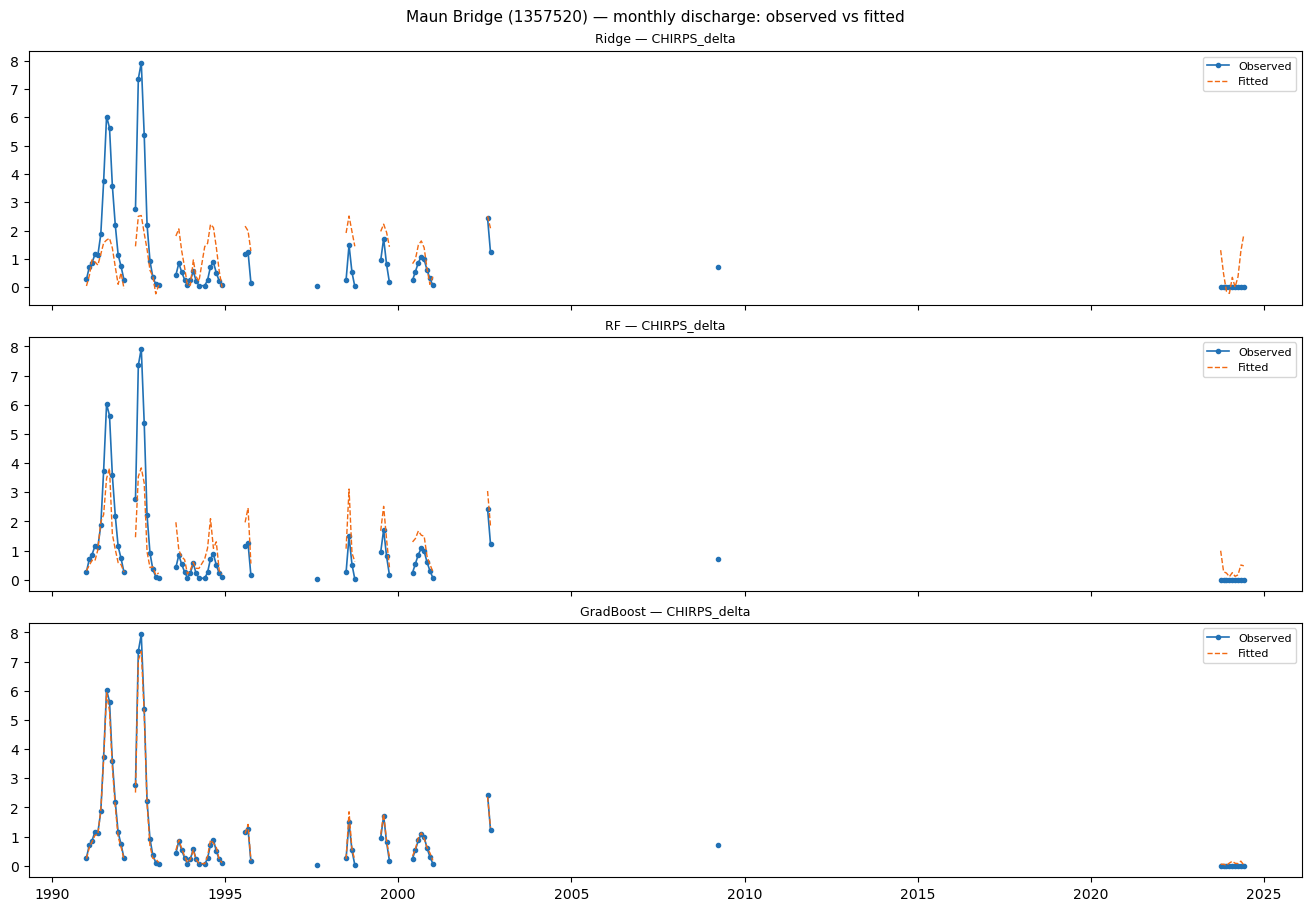

In [20]:
import matplotlib.dates as mdates
import copy as _copy

def _insert_gap_nans(index, values, max_gap_months=3):
    """Insert NaNs where consecutive timestamps are more than max_gap_months apart,
    so matplotlib breaks the line instead of interpolating across the gap."""
    idx = pd.DatetimeIndex(index)
    vals = np.array(values, dtype=float)
    new_idx, new_vals = [idx[0]], [vals[0]]
    gap = pd.Timedelta(days=max_gap_months * 31)
    for i in range(1, len(idx)):
        if idx[i] - idx[i - 1] > gap:
            new_idx.append(idx[i] - pd.Timedelta(days=1))
            new_vals.append(np.nan)
        new_idx.append(idx[i])
        new_vals.append(vals[i])
    return pd.DatetimeIndex(new_idx), np.array(new_vals)

def fit_and_plot_monthly(feat_df, target_monthly, pred_cols, model_name="Ridge",
                          title="", ax=None):
    """Fit on full data, overlay fitted vs observed monthly discharge."""
    avail  = [c for c in pred_cols if c in feat_df.columns]
    df     = feat_df[avail].join(target_monthly.rename("y")).dropna()
    X, y   = df[avail].values, df["y"].values
    m = _copy.deepcopy(MODELS[model_name])
    m.fit(X, y)
    y_hat  = m.predict(X)

    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 3))
    idx_obs, y_obs = _insert_gap_nans(df.index, y)
    idx_fit, y_fit = _insert_gap_nans(df.index, y_hat)
    ax.plot(idx_obs, y_obs, marker='.', lw=1.2, color="#2171b5", label="Observed")
    ax.plot(idx_fit, y_fit, lw=1.0, color="#f16913", ls="--", label="Fitted")
    ax.set_title(title or model_name, fontsize=9)
    ax.xaxis.set_major_locator(mdates.YearLocator(5))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.legend(fontsize=8)
    return ax

# ── Plot best predictor sets for each model ──────────────────────────────────
maun_q = monthly_q.get(MAUN_ID, pd.Series(dtype=float))
if not maun_q.empty:
    maun_q.index = pd.to_datetime(maun_q.index).to_period("M").to_timestamp()

best_pset_name = (results_df.mean(axis=1).idxmax()
                  if not results_df.empty else list(PRED_SETS.keys())[0])
best_cols = PRED_SETS[best_pset_name]

fig, axes = plt.subplots(len(MODELS), 1, figsize=(13, 3 * len(MODELS)),
                         constrained_layout=True, sharex=True)
for ax, mname in zip(axes, MODELS):
    fit_and_plot_monthly(feat_lagged, maun_q, best_cols, model_name=mname,
                         title=f"{mname} — {best_pset_name}", ax=ax)
fig.suptitle(f"Maun Bridge ({MAUN_ID}) — monthly discharge: observed vs fitted",
             fontsize=11)
fig.savefig(FIG_OUT / "monthly_fitted_maun.png", dpi=150)
plt.show()

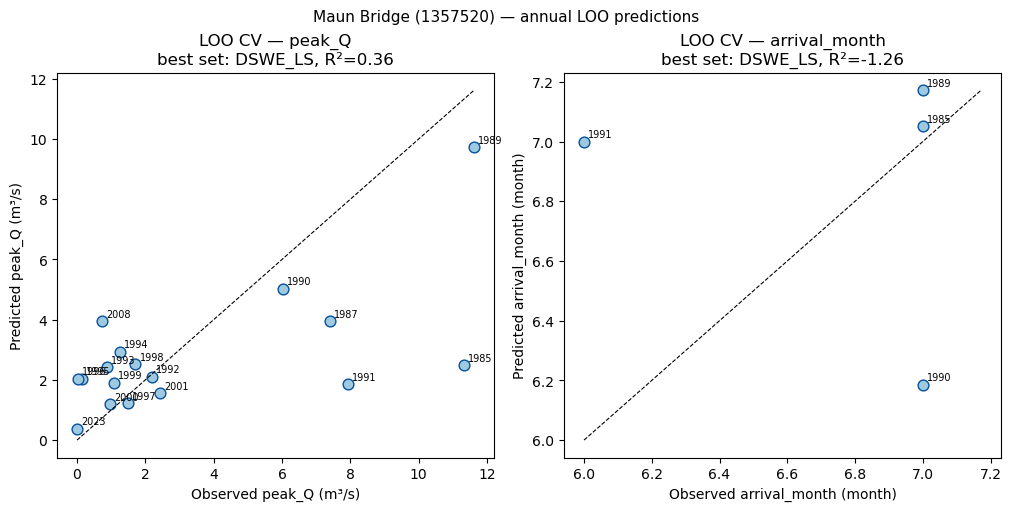

In [ ]:
# ── LOO scatter plots for annual targets ─────────────────────────────────────
n_targets = len(annual_results)
if n_targets:
    fig, axes = plt.subplots(1, n_targets, figsize=(5 * n_targets, 5),
                             constrained_layout=True)
    if n_targets == 1:
        axes = [axes]
    for ax, (tname, res) in zip(axes, annual_results.items()):
        df_loo = res["df"]
        if df_loo is None or df_loo.empty:
            continue
        ax.scatter(df_loo["observed"], df_loo["predicted"],
                   edgecolors="#08519c", facecolors="#9ecae1", s=60)
        lims = [min(df_loo.min()), max(df_loo.max())]
        ax.plot(lims, lims, "k--", lw=0.8)
        labels = {str(wy): (obs, pred)
                  for wy, obs, pred in zip(df_loo.index,
                                           df_loo["observed"],
                                           df_loo["predicted"])}
        for wy_label, (ox, px) in labels.items():
            ax.annotate(wy_label, (ox, px), fontsize=7,
                        xytext=(3, 3), textcoords="offset points")
        unit = "month" if tname == "arrival_month" else "m³/s"
        ax.set_xlabel(f"Observed {tname} ({unit})")
        ax.set_ylabel(f"Predicted {tname} ({unit})")
        ax.set_title(f"LOO CV — {tname}\nbest set: {res['pred_set']}, R²={res['r2']:.2f}")
    fig.suptitle(f"Maun Bridge ({MAUN_ID}) — annual LOO predictions", fontsize=11)
    fig.savefig(FIG_OUT / "annual_loo_scatter_maun.png", dpi=150)
    plt.show()
else:
    print("No annual LOO results to plot (insufficient data)")

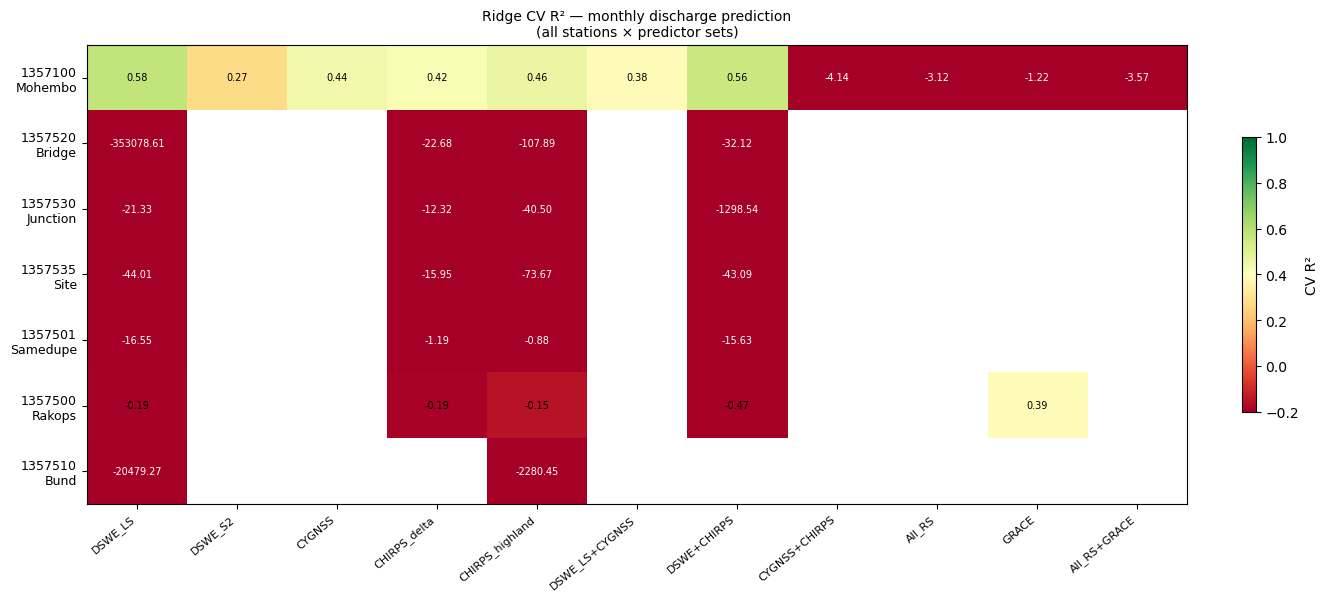

In [ ]:
# ── Heatmap: monthly Ridge R² across all stations × predictor sets ───────────
all_stn_r2_rows = []
for stn_id, stn_info in STATIONS.items():
    q_s = monthly_q.get(stn_id, pd.Series(dtype=float))
    if q_s.dropna().empty:
        continue
    q_s.index = pd.to_datetime(q_s.index).to_period("M").to_timestamp()
    row = {"station": f"{stn_id}\n{stn_info['name'].split()[-1]}"}
    for pset_name, pcols in PRED_SETS.items():
        scores = evaluate_predictor_set(feat_lagged, q_s, pcols, models={"Ridge": MODELS["Ridge"]})
        row[pset_name] = scores.get("Ridge", np.nan)
    all_stn_r2_rows.append(row)

if all_stn_r2_rows:
    heat_df = pd.DataFrame(all_stn_r2_rows).set_index("station")
    fig, ax = plt.subplots(figsize=(max(8, len(heat_df.columns) * 1.2), len(heat_df) * 0.7 + 1),
                           constrained_layout=True)
    im = ax.imshow(heat_df.values.astype(float), aspect="auto",
                   cmap="RdYlGn", vmin=-0.2, vmax=1.0)
    ax.set_xticks(range(len(heat_df.columns)))
    ax.set_xticklabels(heat_df.columns, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(range(len(heat_df.index)))
    ax.set_yticklabels(heat_df.index, fontsize=9)
    for r in range(heat_df.shape[0]):
        for c in range(heat_df.shape[1]):
            val = heat_df.values[r, c]
            if not np.isnan(val):
                ax.text(c, r, f"{val:.2f}", ha="center", va="center", fontsize=7,
                        color="black" if abs(val) < 0.7 else "white")
    plt.colorbar(im, ax=ax, label="CV R²", shrink=0.6)
    ax.set_title("Ridge CV R² — monthly discharge prediction\n(all stations × predictor sets)",
                 fontsize=10)
    fig.savefig(FIG_OUT / "r2_heatmap_all_stations.png", dpi=150)
    plt.show()
else:
    print("No data available for heatmap")

## 10  Summary results

In [ ]:
# ── Monthly CV R² summary (Maun Bridge) ─────────────────────────────────────
print("=" * 60)
print(f"Monthly discharge prediction — Maun Bridge ({MAUN_ID})")
print("=" * 60)
if not results_df.empty:
    print(results_df.to_string())
else:
    print("No results — insufficient overlapping data.")

# ── Annual LOO summary ────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Annual LOO CV — Maun Bridge")
print("=" * 60)
for tname, res in annual_results.items():
    if res["df"] is not None and not res["df"].empty:
        rmse = np.sqrt(((res["df"]["observed"] - res["df"]["predicted"]) ** 2).mean())
        print(f"  {tname:20s}  R²={res['r2']:.3f}  RMSE={rmse:.2f}")
        print(f"    best predictor set: {res['pred_set']}")

# ── Save CSVs ─────────────────────────────────────────────────────────────────
FIG_OUT.mkdir(parents=True, exist_ok=True)
if not results_df.empty:
    results_df.to_csv(FIG_OUT / "monthly_cv_r2_maun.csv")
    print(f"\nSaved: {FIG_OUT / 'monthly_cv_r2_maun.csv'}")
for tname, res in annual_results.items():
    if res["df"] is not None and not res["df"].empty:
        fname = FIG_OUT / f"annual_loo_{tname}_maun.csv"
        res["df"].to_csv(fname)
        print(f"Saved: {fname}")
print("\nDone.")

Monthly discharge prediction — Maun Bridge (1357520)
model             GradBoost          RF       Ridge
predictor_set                                      
CHIRPS_delta        -29.989     -18.821     -22.685
DSWE+CHIRPS         -37.360     -30.199     -32.123
CHIRPS_highland    -114.292    -107.893    -107.888
DSWE_LS         -119193.392 -203601.221 -353078.611
GRACE                   NaN         NaN         NaN

Annual LOO CV — Maun Bridge
  peak_Q                R²=0.360  RMSE=3.04
    best predictor set: DSWE_LS
  arrival_month         R²=-1.262  RMSE=0.65
    best predictor set: DSWE_LS

Saved: ../figures/flood_prediction/monthly_cv_r2_maun.csv
Saved: ../figures/flood_prediction/annual_loo_peak_Q_maun.csv
Saved: ../figures/flood_prediction/annual_loo_arrival_month_maun.csv

Done.


In [ ]:
import datetime
print("Last edited:", datetime.date.today())

Last edited: 2026-03-10
